In [1]:
# ─── 0. Kiểm tra môi trường Kaggle ──────────────────────────────────────────
import os, torch

IS_KAGGLE = os.path.exists('/kaggle')
IS_COLAB  = 'google.colab' in str(globals().get('__builtins__', ''))

print(f" Môi trường  : {'Kaggle' if IS_KAGGLE else 'Colab' if IS_COLAB else 'Local'}")
print(f" Python      : {os.sys.version.split()[0]}")
print(f" PyTorch     : {torch.__version__}")
print(f"  CUDA        : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU         : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM        : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
    print(f"   CUDA version: {torch.version.cuda}")

# Kaggle: GPU T4 ~16GB → batch_size=8 ổn
# Kaggle: GPU P100 ~16GB → batch_size=8-16 ổn
# Kaggle: không có GPU → batch_size=2, tắt RL
print(f"\n /kaggle/input contents:")
if IS_KAGGLE:
    for item in sorted(os.listdir('/kaggle/input')):
        print(f"   {item}/")
        sub = f"/kaggle/input/{item}"
        for f in os.listdir(sub)[:5]:
            size = os.path.getsize(f"{sub}/{f}") / 1e6
            print(f"     {f}  ({size:.1f} MB)")
else:
    print("   (không phải Kaggle)")


 Môi trường  : Kaggle
 Python      : 3.12.13
 PyTorch     : 2.10.0+cu128
  CUDA        : True
   GPU         : Tesla T4
   VRAM        : 15.6 GB
   CUDA version: 12.8

 /kaggle/input contents:
   datasets/
     vinhaaa  (0.0 MB)


## 1. Cài đặt thư viện

In [2]:
# ─── Cài đặt thư viện ────────────────────────────────────────────────────────
# Kaggle: Python 3.10, GPU T4/P100, transformers thường đã có sẵn
# → chỉ cài thêm những gì thiếu, pin version để tránh xung đột

import subprocess, sys

pkgs = [
    "transformers>=4.44.0,<4.48.0",
    "datasets>=2.18.0",
    "sentencepiece",
    "accelerate>=0.27.0",
    "rouge-score",
    "bert-score",
    "sacrebleu",
    "pyarrow",          # đọc .parquet
    "underthesea",      # tokenizer tiếng Việt
    "pyvi",
]

print(" Cài đặt thư viện...")
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "--upgrade"] + pkgs,
    check=True
)

import nltk
for pkg in ['wordnet', 'punkt', 'punkt_tab', 'omw-1.4']:
    nltk.download(pkg, quiet=True)

# ── Kiểm tra version ─────────────────────────────────────────────────────────
import importlib
print("\n Versions:")
for lib in ['transformers', 'datasets', 'torch', 'accelerate']:
    try:
        m = importlib.import_module(lib)
        print(f"   {lib:<18} {m.__version__}")
    except Exception as e:
        print(f"   {lib}: {e}")

import torch
print(f"\n  Device: {'CUDA (' + torch.cuda.get_device_name(0) + ')' if torch.cuda.is_available() else 'CPU'}")
print("\n Cài đặt xong! Tiếp tục chạy các cell bên dưới.")


 Cài đặt thư viện...

 Versions:
   transformers       4.47.1
   datasets           5.0.0
   torch              2.10.0+cu128
   accelerate         1.13.0

  Device: CUDA (Tesla T4)

 Cài đặt xong! Tiếp tục chạy các cell bên dưới.


## 2. Import & Cấu hình

In [3]:
import os, math, warnings, json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional
warnings.filterwarnings('ignore')

# ── Transformers: chỉ import những gì dùng (tránh lazy-load peft) ─────────
from transformers import AutoTokenizer, AutoModel, AutoModelForSeq2SeqLM
from transformers import get_cosine_schedule_with_warmup
from datasets import Dataset, DatasetDict

# ── Metrics ───────────────────────────────────────────────────────────────
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
import sacrebleu

# ── Device ────────────────────────────────────────────────────────────────
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f" Device: {DEVICE.upper()}")
if DEVICE == "cuda":
    print(f"   GPU : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

# Kiểm tra nhanh import transformers core
import transformers
print(f"   transformers: {transformers.__version__}")


 Device: CUDA
   GPU : Tesla T4
   VRAM: 15.6 GB
   transformers: 4.47.1


## 3. Cấu hình Hyperparameters

In [4]:
@dataclass
class TrainingConfig:
    # Model
    encoder_model:   str   = "vinai/phobert-base-v2"   # PhoBERT cho tiếng Việt
    decoder_model:   str   = "google/mt5-small"         # mT5 decoder
    
    # Data
    max_input_len:   int   = 256
    max_target_len:  int   = 80
    prefix:          str   = "tóm tắt: "
    
    # Training
    num_epochs:      int   = 10
    batch_size:      int   = 8
    grad_accum:      int   = 4
    learning_rate:   float = 5e-5
    weight_decay:    float = 0.01
    warmup_ratio:    float = 0.06
    
    # RL settings
    mle_warmup_epochs: int   = 3     # Epoch đầu chỉ dùng MLE
    alpha_min:         float = 0.5   # Tỉ lệ MLE tối thiểu
    rl_temperature:    float = 0.9   # Temperature khi sample
    
    # Reward weights
    w_rouge:    float = 0.40
    w_bert:     float = 0.30
    w_fluency:  float = 0.15
    w_length:   float = 0.15
    target_compression: float = 0.30  # 30% độ dài source
    
    # Output
    output_dir: str = "/kaggle/working/mt5_vi_summarization"  # Kaggle lưu output tại đây

cfg = TrainingConfig()
print(" Config:")
for k, v in vars(cfg).items():
    print(f"   {k:<25} = {v}")


 Config:
   encoder_model             = vinai/phobert-base-v2
   decoder_model             = google/mt5-small
   max_input_len             = 256
   max_target_len            = 80
   prefix                    = tóm tắt: 
   num_epochs                = 10
   batch_size                = 8
   grad_accum                = 4
   learning_rate             = 5e-05
   weight_decay              = 0.01
   warmup_ratio              = 0.06
   mle_warmup_epochs         = 3
   alpha_min                 = 0.5
   rl_temperature            = 0.9
   w_rouge                   = 0.4
   w_bert                    = 0.3
   w_fluency                 = 0.15
   w_length                  = 0.15
   target_compression        = 0.3
   output_dir                = /kaggle/working/mt5_vi_summarization


## 4. Chuẩn bị Dữ liệu Tiếng Việt

In [5]:
# ─── 4.1 Vietnamese Preprocessor ────────────────────────────────────────────
class VietnamesePreprocessor:
    """Tiền xử lý văn bản tiếng Việt"""
    
    def __init__(self):
        self.use_underthesea = self._check_underthesea()
    
    def _check_underthesea(self):
        try:
            from underthesea import word_tokenize
            self.word_tokenize = word_tokenize
            return True
        except ImportError:
            return False
    
    def normalize(self, text: str) -> str:
        import unicodedata, re
        text = unicodedata.normalize('NFC', text)
        text = re.sub(r'\s+', ' ', text)
        text = re.sub(r'([.!?])\s*([.!?])+', r'\1', text)
        abbreviations = {
            'tp.hcm': 'thành phố hồ chí minh',
            'tp.hn' : 'thành phố hà nội',
            'đ/c'   : 'địa chỉ',
        }
        for abbr, full in abbreviations.items():
            text = re.sub(r'\b' + re.escape(abbr) + r'\b',
                          full, text, flags=re.IGNORECASE)
        return text.strip()
    
    def tokenize(self, text: str) -> str:
        text = self.normalize(text)
        if self.use_underthesea:
            text = self.word_tokenize(text, format='text')
        return text

preprocessor = VietnamesePreprocessor()
print(f" VietnamesePreprocessor khởi tạo "
      f"(underthesea: {preprocessor.use_underthesea})")


 VietnamesePreprocessor khởi tạo (underthesea: True)


In [6]:
# ─── 4.2a  ⚙️ CẤU HÌNH ĐƯỜNG DẪN ───────────────────────────────────────────
import os, pandas as pd
from datasets import Dataset, DatasetDict

# Kaggle: file upload nằm ở /kaggle/input/<dataset-name>/
# Ví dụ nếu dataset tên "vi-summarization":
#   TRAIN_PATH = "/kaggle/input/vi-summarization/train.parquet"

# ── Tự động tìm file .parquet nếu không biết chắc đường dẫn ─────────────────
def find_parquet(hint="train"):
    """Tìm file parquet theo từ khoá hint trong /kaggle/input hoặc thư mục hiện tại"""
    search_dirs = ["/kaggle/input", ".", "/kaggle/working"]
    for d in search_dirs:
        if not os.path.exists(d):
            continue
        for root, _, files in os.walk(d):
            for f in files:
                if f.endswith(".parquet") and hint.lower() in f.lower():
                    return os.path.join(root, f)
    return None

# Tự detect hoặc tự điền thủ công
TRAIN_PATH = find_parquet("train") or "train.parquet"
VALID_PATH = find_parquet("valid") or find_parquet("val") or "valid.parquet"
# TEST_PATH = find_parquet("test")  # bỏ comment khi có

SRC_COL = "document"   # ← đổi nếu tên cột khác
TGT_COL = "summary"    # ← đổi nếu tên cột khác

print(f" Đường dẫn:")
print(f"   TRAIN : {TRAIN_PATH}  {'✅' if os.path.exists(TRAIN_PATH) else '❌ KHÔNG TÌM THẤY'}")
print(f"   VALID : {VALID_PATH}  {'✅' if os.path.exists(VALID_PATH) else '❌ KHÔNG TÌM THẤY'}")
print(f"   Cột   : '{SRC_COL}' → '{TGT_COL}'")


 Đường dẫn:
   TRAIN : /kaggle/input/datasets/vinhaaa/text-sum2/train.parquet  ✅
   VALID : /kaggle/input/datasets/vinhaaa/text-sum/valid.parquet  ✅
   Cột   : 'document' → 'summary'


In [7]:
# ─── 4.2b  Load & kiểm tra dữ liệu ─────────────────────────────────────────
def load_parquet_dataset(train_path, valid_path,
                          src_col=SRC_COL, tgt_col=TGT_COL):
    splits = {}
    for split_name, path in [('train', train_path), ('validation', valid_path)]:
        if path is None:
            continue
        print(f"⏳ Đọc {split_name}: {path}")
        df = pd.read_parquet(path)

        # Kiểm tra cột — tự detect nếu sai tên
        missing = [c for c in [src_col, tgt_col] if c not in df.columns]
        if missing:
            print(f"   ⚠️  Không tìm thấy cột {missing}")
            print(f"   Các cột hiện có: {list(df.columns)}")
            if len(df.columns) >= 2:
                src_col_use, tgt_col_use = df.columns[0], df.columns[1]
                print(f"   → Tự dùng: src='{src_col_use}', tgt='{tgt_col_use}'")
                df = df.rename(columns={src_col_use: src_col,
                                        tgt_col_use: tgt_col})

        # Làm sạch
        before = len(df)
        df = df[[src_col, tgt_col]].dropna()
        df = df[df[src_col].str.strip().ne('') &
                df[tgt_col].str.strip().ne('')]
        removed = before - len(df)
        if removed:
            print(f"   🗑️  Bỏ {removed} hàng null/rỗng")

        splits[split_name] = Dataset.from_pandas(
            df[[src_col, tgt_col]], preserve_index=False)

        src_lens = df[src_col].str.split().str.len()
        tgt_lens = df[tgt_col].str.split().str.len()
        print(f"   ✅ {split_name}: {len(df):,} mẫu")
        print(f"      Nguồn  — avg={src_lens.mean():.0f} từ  "
              f"(min={src_lens.min()}, max={src_lens.max()})")
        print(f"      Tóm tắt— avg={tgt_lens.mean():.0f} từ  "
              f"(min={tgt_lens.min()}, max={tgt_lens.max()})")
        print(f"      Compression avg: "
              f"{(tgt_lens/src_lens.clip(1)).mean():.2%}")

    return DatasetDict(splits), src_col, tgt_col

# ── Thực thi ─────────────────────────────────────────────────────────────────
dataset, src_col, tgt_col = load_parquet_dataset(TRAIN_PATH, VALID_PATH)

print(f"\n Ví dụ mẫu [0]:")
s = dataset['train'][0]
print(f"  [{src_col}] {str(s[src_col])[:200]}...")
print(f"  [{tgt_col}] {s[tgt_col]}")


⏳ Đọc train: /kaggle/input/datasets/vinhaaa/text-sum2/train.parquet
   ⚠️  Không tìm thấy cột ['document']
   Các cột hiện có: ['article', 'summary']
   → Tự dùng: src='article', tgt='summary'
   ✅ train: 10,775 mẫu
      Nguồn  — avg=458 từ  (min=300, max=700)
      Tóm tắt— avg=103 từ  (min=50, max=174)
      Compression avg: 23.16%
⏳ Đọc validation: /kaggle/input/datasets/vinhaaa/text-sum/valid.parquet
   ⚠️  Không tìm thấy cột ['document']
   Các cột hiện có: ['article', 'summary']
   → Tự dùng: src='article', tgt='summary'
   ✅ validation: 1,349 mẫu
      Nguồn  — avg=466 từ  (min=300, max=700)
      Tóm tắt— avg=102 từ  (min=54, max=164)
      Compression avg: 22.67%

 Ví dụ mẫu [0]:
  [document] Gần 20 sự kiện được tổ chức trên toàn thành phố, kéo dài từ 19/4 đến 10/5. Theo Sở Du lịch Hà Nội, ngoài thu hút du khách, loạt sự kiện cũng là các gợi ý dành cho người dân thủ đô không đi chơi xa và ...
  [summary] Hà Nội tổ chức gần 20 sự kiện từ 19/4 đến 10/5, bao gồm Lễ hội Du lịch H

In [8]:
# ─── 4.3 Tokenization ───────────────────────────────────────────────────────
encoder_tokenizer = AutoTokenizer.from_pretrained(cfg.encoder_model)
decoder_tokenizer = AutoTokenizer.from_pretrained(cfg.decoder_model)

# giữ biến tokenizer để các phần decoder/generation hiện tại vẫn hoạt động
tokenizer = decoder_tokenizer

def preprocess_function(examples):
    inputs  = [cfg.prefix + preprocessor.normalize(doc)
               for doc in examples[src_col]]
    targets = [preprocessor.normalize(s) for s in examples[tgt_col]]

    model_inputs = encoder_tokenizer(
        inputs,
        max_length=cfg.max_input_len,
        truncation=True,
        padding='max_length'
    )
    labels = decoder_tokenizer(
        text_target=targets,
        max_length=cfg.max_target_len,
        truncation=True,
        padding='max_length'
    )
    # padding token → -100 (bỏ qua khi tính loss)
    labels['input_ids'] = [
        [(t if t != decoder_tokenizer.pad_token_id else -100) for t in lbl]
        for lbl in labels['input_ids']
    ]
    model_inputs['labels']          = labels['input_ids']
    model_inputs['source_texts']    = examples[src_col]
    model_inputs['reference_texts'] = examples[tgt_col]
    return model_inputs

print("⏳ Tokenizing...")
remove_cols = [c for c in dataset['train'].column_names
               if c not in [src_col, tgt_col]]
tokenized = dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=remove_cols,
    desc="Tokenizing"
)
print(f"✅ Tokenization xong!")
print(f"   Train:      {len(tokenized['train']):,} mẫu")
print(f"   Validation: {len(tokenized['validation']):,} mẫu")
print(f"   Features:   {list(tokenized['train'].features.keys())}")


You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


⏳ Tokenizing...


Tokenizing:   0%|          | 0/10775 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/1349 [00:00<?, ? examples/s]

✅ Tokenization xong!
   Train:      10,775 mẫu
   Validation: 1,349 mẫu
   Features:   ['document', 'summary', 'input_ids', 'token_type_ids', 'attention_mask', 'labels', 'source_texts', 'reference_texts']


In [9]:
# ─── 4.4 Load Test set (chạy cell này khi đã có file test) ──────────────────
# Bỏ comment và điền đường dẫn khi có dữ liệu test

# TEST_PATH = "test.parquet"
#
# def load_test_parquet(test_path, src_col=SRC_COL, tgt_col=TGT_COL):
#     print(f"⏳ Đọc test: {test_path}")
#     df = pd.read_parquet(test_path).dropna(subset=[src_col, tgt_col])
#     df = df[df[src_col].str.strip().ne('') & df[tgt_col].str.strip().ne('')]
#     test_ds = Dataset.from_pandas(df[[src_col, tgt_col]], preserve_index=False)
#     print(f"✅ Test: {len(test_ds):,} mẫu")
#     return test_ds
#
# test_dataset = load_test_parquet(TEST_PATH)
#
# # Tokenize test set
# tokenized_test = test_dataset.map(
#     preprocess_function,
#     batched=True,
#     remove_columns=[c for c in test_dataset.column_names
#                     if c not in [src_col, tgt_col]],
#     desc="Tokenizing test"
# )
# print(f"✅ Test tokenized: {len(tokenized_test):,} mẫu")

print("ℹ️  Cell này dùng để load test set khi có dữ liệu.")
print("   Bỏ comment và chạy lại khi file test.parquet sẵn sàng.")


ℹ️  Cell này dùng để load test set khi có dữ liệu.
   Bỏ comment và chạy lại khi file test.parquet sẵn sàng.


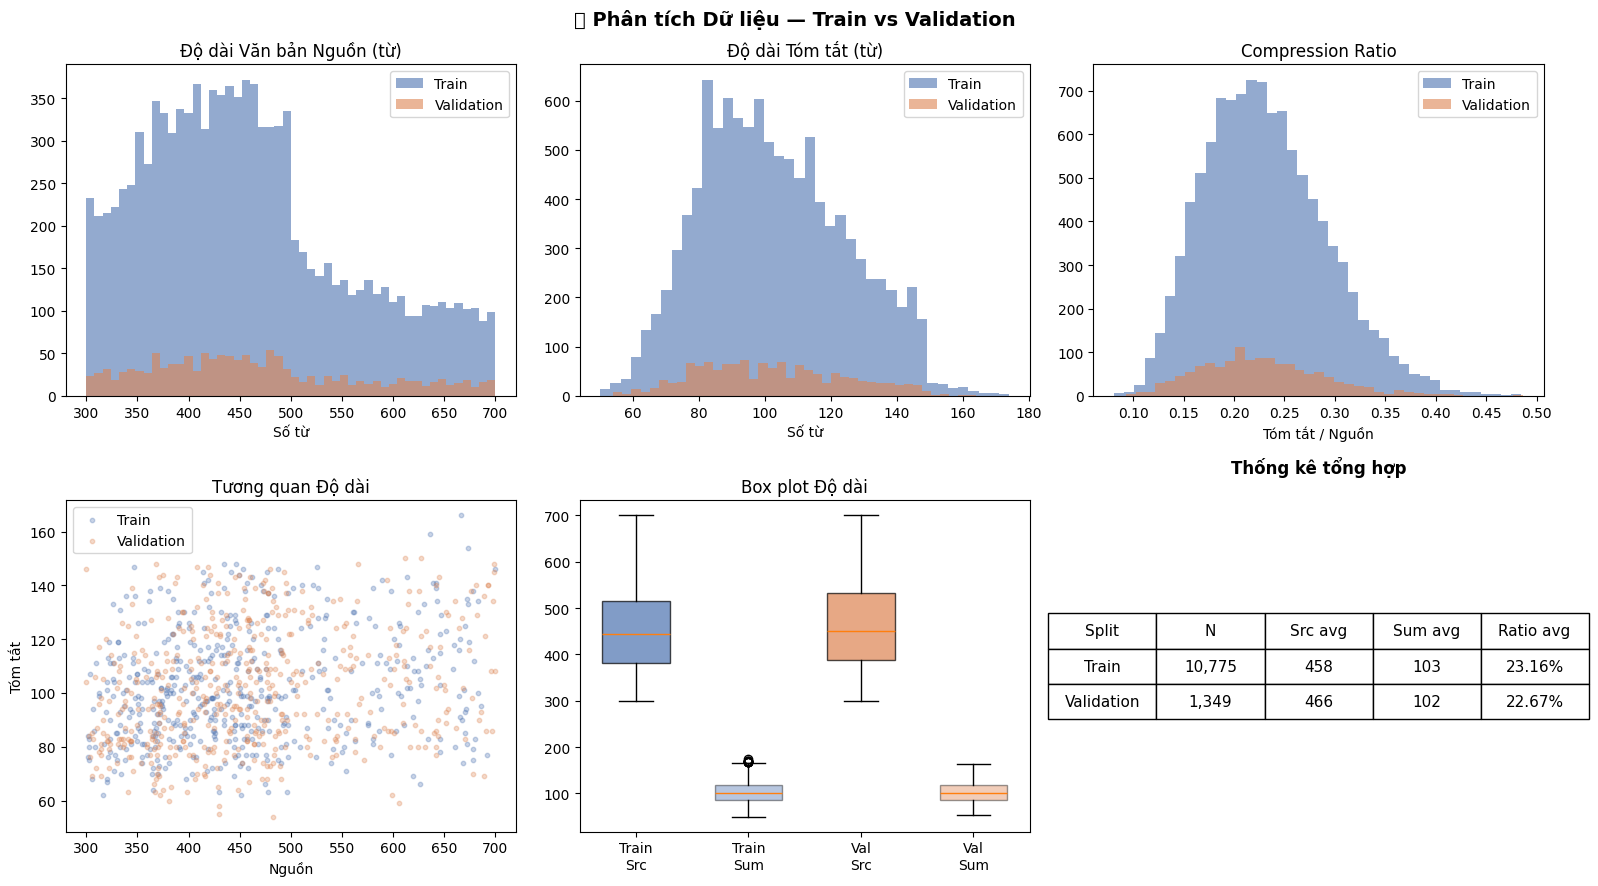

✅ Lưu biểu đồ: data_analysis.png


In [10]:
# ─── 4.5 Phân tích thống kê dữ liệu (EDA) ──────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def plot_data_stats(dataset, src_col, tgt_col):
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig.suptitle('📊 Phân tích Dữ liệu — Train vs Validation',
                 fontsize=14, fontweight='bold')

    colors = {'train': '#4C72B0', 'validation': '#DD8452'}

    for split_name, color in colors.items():
        if split_name not in dataset: continue
        df = dataset[split_name].to_pandas()
        src_lens = df[src_col].str.split().str.len()
        tgt_lens = df[tgt_col].str.split().str.len()
        ratio    = tgt_lens / src_lens.clip(1)

        label = split_name.capitalize()

        # 1. Phân phối độ dài nguồn
        axes[0,0].hist(src_lens.clip(0,800), bins=50, alpha=0.6,
                       color=color, label=label)
        # 2. Phân phối độ dài tóm tắt
        axes[0,1].hist(tgt_lens.clip(0,200), bins=40, alpha=0.6,
                       color=color, label=label)
        # 3. Compression ratio
        axes[0,2].hist(ratio.clip(0,1), bins=40, alpha=0.6,
                       color=color, label=label)
        # 4. Scatter: src_len vs tgt_len
        sample_n = min(500, len(df))
        idx = df.sample(sample_n, random_state=42).index
        axes[1,0].scatter(src_lens[idx], tgt_lens[idx],
                          alpha=0.3, s=10, color=color, label=label)
        # 5. Box plot độ dài
        pos = 1 if split_name == 'train' else 2
        axes[1,1].boxplot(src_lens.clip(0,1000),
                          positions=[pos*2-1], widths=0.6,
                          patch_artist=True,
                          boxprops=dict(facecolor=color, alpha=0.7))
        axes[1,1].boxplot(tgt_lens.clip(0,200),
                          positions=[pos*2], widths=0.6,
                          patch_artist=True,
                          boxprops=dict(facecolor=color, alpha=0.4))

    axes[0,0].set_title('Độ dài Văn bản Nguồn (từ)'); axes[0,0].set_xlabel('Số từ'); axes[0,0].legend()
    axes[0,1].set_title('Độ dài Tóm tắt (từ)');       axes[0,1].set_xlabel('Số từ'); axes[0,1].legend()
    axes[0,2].set_title('Compression Ratio');          axes[0,2].set_xlabel('Tóm tắt / Nguồn'); axes[0,2].legend()
    axes[1,0].set_title('Tương quan Độ dài'); axes[1,0].set_xlabel('Nguồn'); axes[1,0].set_ylabel('Tóm tắt'); axes[1,0].legend()
    axes[1,1].set_title('Box plot Độ dài')
    axes[1,1].set_xticks([1,2,3,4])
    axes[1,1].set_xticklabels(['Train\nSrc','Train\nSum','Val\nSrc','Val\nSum'])

    # 6. Bảng thống kê
    axes[1,2].axis('off')
    rows, cols_label = [], ['Split','N','Src avg','Sum avg','Ratio avg']
    for split_name in ['train','validation']:
        if split_name not in dataset: continue
        df = dataset[split_name].to_pandas()
        sl = df[src_col].str.split().str.len()
        tl = df[tgt_col].str.split().str.len()
        r  = tl / sl.clip(1)
        rows.append([split_name.capitalize(), f"{len(df):,}",
                     f"{sl.mean():.0f}", f"{tl.mean():.0f}", f"{r.mean():.2%}"])
    tbl = axes[1,2].table(cellText=rows, colLabels=cols_label,
                           loc='center', cellLoc='center')
    tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1.2, 2)
    axes[1,2].set_title('Thống kê tổng hợp', fontweight='bold', pad=20)

    plt.tight_layout()
    plt.savefig('data_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Lưu biểu đồ: data_analysis.png")

plot_data_stats(dataset, src_col, tgt_col)


## 5. Kiến trúc Mô hình: PhoBERT Encoder + mT5 Decoder

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from types import SimpleNamespace

from transformers import (
    AutoModel,
    AutoModelForSeq2SeqLM
)

from transformers.modeling_outputs import BaseModelOutput


class ViSumModel(nn.Module):
    """
    PhoBERT Encoder
        ↓
    Bridge (768 -> 512)
        ↓
    mT5 Decoder
    """

    def __init__(self, cfg):
        super().__init__()

        self.cfg = cfg

        # =========================
        # PhoBERT Encoder
        # =========================
        self.encoder = AutoModel.from_pretrained(
            cfg.encoder_model
        )

        phobert_dim = self.encoder.config.hidden_size  # 768

        # =========================
        # mT5
        # =========================
        self.mt5 = AutoModelForSeq2SeqLM.from_pretrained(
            cfg.decoder_model
        )

        self.decoder = self.mt5.decoder
        self.lm_head = self.mt5.lm_head
        self.config = self.mt5.config

        mt5_dim = self.config.d_model  # 512

        # =========================
        # Bridge
        # =========================
        self.bridge = nn.Sequential(
            nn.Linear(phobert_dim, mt5_dim),
            nn.LayerNorm(mt5_dim),
            nn.GELU(),
            nn.Dropout(0.1)
        )

        self.vocab_size = self.config.vocab_size
        self.encoder.gradient_checkpointing_enable()
        self.mt5.gradient_checkpointing_enable()

    # =====================================================
    # Encoder
    # =====================================================
    def get_encoder_output(
        self,
        input_ids,
        attention_mask
    ):

        enc_out = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        hidden = enc_out.last_hidden_state

        bridged = self.bridge(hidden)

        assert (
            bridged.size(-1)
            == self.config.d_model
        ), f"Bridge output dim {bridged.size(-1)} != {self.config.d_model}"

        return bridged

    # =====================================================
    # Shift Right
    # =====================================================
    def _shift_right(self, labels):

        shifted = labels.new_zeros(labels.shape)

        shifted[:, 1:] = labels[:, :-1].clone()

        pad_id = self.config.pad_token_id

        shifted[shifted == -100] = pad_id

        start_id = self.config.decoder_start_token_id

        if start_id is None:
            start_id = pad_id

        shifted[:, 0] = start_id

        return shifted

    # =====================================================
    # Forward
    # =====================================================
    def forward(
        self,
        input_ids,
        attention_mask,
        labels=None,
        decoder_input_ids=None
    ):

        encoder_hidden = self.get_encoder_output(
            input_ids,
            attention_mask
        )

        if decoder_input_ids is None and labels is not None:
            decoder_input_ids = self._shift_right(labels)

        decoder_outputs = self.decoder(
            input_ids=decoder_input_ids,
            encoder_hidden_states=encoder_hidden,
            encoder_attention_mask=attention_mask,
            return_dict=True
        )

        logits = self.lm_head(
            decoder_outputs.last_hidden_state
        )

        loss = None

        if labels is not None:

            loss = F.cross_entropy(
                logits.reshape(-1, self.vocab_size),
                labels.reshape(-1),
                ignore_index=-100
            )

        return SimpleNamespace(
            loss=loss,
            logits=logits,
            encoder_hidden=encoder_hidden
        )

    # =====================================================
    # Generate
    # =====================================================
    @torch.no_grad()
    def generate(
        self,
        input_ids,
        attention_mask,
        max_length=150,
        min_length=40,
        num_beams=4,
        no_repeat_ngram_size=3,
        **kwargs
    ):

        encoder_hidden = self.get_encoder_output(
            input_ids,
            attention_mask
        )

        encoder_outputs = BaseModelOutput(
            last_hidden_state=encoder_hidden
        )

        generated = self.mt5.generate(
            encoder_outputs=encoder_outputs,
            attention_mask=attention_mask,
            max_length=max_length,
            min_length=min_length,
            num_beams=num_beams,
            no_repeat_ngram_size=no_repeat_ngram_size,
            early_stopping=True,
            length_penalty=2.0,
            **kwargs
        )

        return generated

## 6. Hệ thống Evaluation Metrics

In [12]:
# ─── 6.1 ROUGE ──────────────────────────────────────────────────────────────
class ROUGEMetrics:
    """ROUGE-1, ROUGE-2, ROUGE-L, ROUGE-Lsum"""
    def __init__(self):
        self.scorer = rouge_scorer.RougeScorer(
            ['rouge1', 'rouge2', 'rougeL', 'rougeLsum'],
            use_stemmer=False
        )
    
    def compute(self, predictions: List[str],
                references:  List[str]) -> Dict:
        all_scores = {k: [] for k in ['rouge1','rouge2','rougeL','rougeLsum']}
        for pred, ref in zip(predictions, references):
            s = self.scorer.score(ref, pred)
            for k in all_scores:
                all_scores[k].append({
                    'precision': s[k].precision,
                    'recall':    s[k].recall,
                    'fmeasure':  s[k].fmeasure
                })
        return {
            k: {m: np.mean([sc[m] for sc in v])
                for m in ['precision','recall','fmeasure']}
            for k, v in all_scores.items()
        }

print("✅ ROUGEMetrics định nghĩa xong")


✅ ROUGEMetrics định nghĩa xong


In [13]:
# ─── 6.2 BLEU & METEOR ──────────────────────────────────────────────────────
class BLEUMETEORMetrics:
    """BLEU-1/2/4, SacreBLEU, METEOR"""
    
    def compute_bleu(self, predictions: List[str],
                     references:  List[str]) -> Dict:
        smooth = SmoothingFunction().method3
        refs_tok  = [[r.split()] for r in references]
        preds_tok = [p.split()   for p in predictions]
        
        bleu1 = corpus_bleu(refs_tok, preds_tok, weights=(1,0,0,0),
                            smoothing_function=smooth)
        bleu2 = corpus_bleu(refs_tok, preds_tok, weights=(.5,.5,0,0),
                            smoothing_function=smooth)
        bleu4 = corpus_bleu(refs_tok, preds_tok, weights=(.25,)*4,
                            smoothing_function=smooth)
        sb    = sacrebleu.corpus_bleu(predictions, [references])
        return {
            'bleu1':     round(bleu1 * 100, 2),
            'bleu2':     round(bleu2 * 100, 2),
            'bleu4':     round(bleu4 * 100, 2),
            'sacrebleu': round(sb.score,    2),
        }
    
    def compute_meteor(self, predictions: List[str],
                       references:  List[str]) -> Dict:
        scores = [meteor_score([r.split()], p.split())
                  for p, r in zip(predictions, references)]
        return {'meteor': round(np.mean(scores) * 100, 2)}

print("✅ BLEUMETEORMetrics định nghĩa xong")


✅ BLEUMETEORMetrics định nghĩa xong


In [14]:
# ─── 6.3 BERTScore ──────────────────────────────────────────────────────────
class BERTScoreMetric:
    """
    BERTScore dùng PhoBERT — bắt được paraphrase mà ROUGE bỏ sót.
    Nếu không có GPU, dùng multilingual-BERT thay thế.
    """
    def __init__(self, device=DEVICE):
        self.device     = device
        self.model_type = ("vinai/phobert-base-v2" if device == "cuda"
                           else "bert-base-multilingual-cased")
    
    def compute(self, predictions: List[str],
                references:  List[str], batch_size=16) -> Dict:
        try:
            from bert_score import score as _score
            P, R, F1 = _score(
                cands=predictions, refs=references,
                model_type=self.model_type,
                lang='vi', device=self.device,
                batch_size=batch_size, verbose=False
            )
            return {
                'bertscore_p':  round(P.mean().item()  * 100, 2),
                'bertscore_r':  round(R.mean().item()  * 100, 2),
                'bertscore_f1': round(F1.mean().item() * 100, 2),
            }
        except Exception as e:
            print(f"⚠️  BERTScore lỗi: {e}")
            return {'bertscore_p': None, 'bertscore_r': None, 'bertscore_f1': None}

print("✅ BERTScoreMetric định nghĩa xong")


✅ BERTScoreMetric định nghĩa xong


In [15]:
# ─── 6.4 Statistical Metrics ────────────────────────────────────────────────
class StatisticalMetrics:
    """
    Compression Ratio, Density, Coverage, Novelty, Avg Length.
    Đánh giá đặc tính của summary (extractive vs abstractive).
    """
    def compute(self, sources: List[str],
                predictions: List[str]) -> Dict:
        metrics = {k: [] for k in
                   ['compression_ratio','density','coverage',
                    'novelty_1gram','novelty_2gram','avg_length']}
        
        for src, pred in zip(sources, predictions):
            st, pt = src.split(), pred.split()
            
            if st: metrics['compression_ratio'].append(len(pt)/len(st))
            metrics['avg_length'].append(len(pt))
            
            frags = self._extractive_fragments(st, pt)
            density  = np.mean([len(f)**2 for f in frags]) if frags else 0
            covered  = sum(len(f) for f in frags)
            coverage = covered / len(pt) if pt else 0
            metrics['density'].append(density)
            metrics['coverage'].append(coverage)
            
            s1 = set(st); p1 = set(pt)
            metrics['novelty_1gram'].append(
                len(p1-s1)/len(p1) if p1 else 0)
            
            s2 = set(zip(st,st[1:])); p2 = set(zip(pt,pt[1:]))
            metrics['novelty_2gram'].append(
                len(p2-s2)/len(p2) if p2 else 0)
        
        return {k: round(float(np.mean(v))*100, 2) for k,v in metrics.items()}
    
    def _extractive_fragments(self, src, summ):
        frags, i = [], 0
        while i < len(summ):
            best = []
            for j in range(len(src)):
                f = []
                while (i+len(f)<len(summ) and j+len(f)<len(src)
                       and summ[i+len(f)]==src[j+len(f)]):
                    f.append(summ[i+len(f)])
                if len(f) > len(best): best = f
            if best: frags.append(best); i += len(best)
            else: i += 1
        return frags

print("✅ StatisticalMetrics định nghĩa xong")


✅ StatisticalMetrics định nghĩa xong


In [16]:
# ─── 6.5 Unified Evaluator ──────────────────────────────────────────────────
class SummarizationEvaluator:
    """Gộp tất cả độ đo vào một interface duy nhất"""
    
    def __init__(self, device=DEVICE):
        self.rouge      = ROUGEMetrics()
        self.bleu_meteor= BLEUMETEORMetrics()
        self.bert_score = BERTScoreMetric(device)
        self.stats      = StatisticalMetrics()
    
    def evaluate(self, sources: List[str], predictions: List[str],
                 references: List[str], verbose=True) -> Dict:
        results = {}
        print("  📐 ROUGE...");      results['rouge']      = self.rouge.compute(predictions, references)
        print("  📐 BLEU...");       results['bleu']       = self.bleu_meteor.compute_bleu(predictions, references)
        print("  📐 METEOR...");     results['meteor']     = self.bleu_meteor.compute_meteor(predictions, references)
        print("  📐 BERTScore...");  results['bertscore']  = self.bert_score.compute(predictions, references)
        print("  📐 Statistics..."); results['statistics'] = self.stats.compute(sources, predictions)
        if verbose: self._print_report(results)
        return results
    
    def _print_report(self, r):
        SEP = "=" * 58
        print(f"\n{SEP}")
        print("       SUMMARIZATION EVALUATION REPORT")
        print(SEP)
        
        # ROUGE
        print(f"\n{'Metric':<14} {'Precision':>10} {'Recall':>10} {'F1':>10}")
        print("-" * 48)
        for m, s in r['rouge'].items():
            print(f"{m.upper():<14} "
                  f"{s['precision']*100:>9.2f}% "
                  f"{s['recall']*100:>9.2f}% "
                  f"{s['fmeasure']*100:>9.2f}%")
        
        # BLEU & METEOR
        print(f"\n{'BLEU / METEOR'}")
        print("-" * 48)
        for k,v in r['bleu'].items():
            print(f"  {k.upper():<18} {v:>8.2f}")
        print(f"  {'METEOR':<18} {r['meteor']['meteor']:>8.2f}")
        
        # BERTScore
        print(f"\n{'BERTScore (PhoBERT)'}")
        print("-" * 48)
        for k,v in r['bertscore'].items():
            if v is not None:
                print(f"  {k:<22} {v:>8.2f}")
        
        # Statistical
        print(f"\n{'Statistical Metrics'}")
        print("-" * 48)
        st = r['statistics']
        print(f"  Compression Ratio  {st['compression_ratio']:>8.2f}%")
        print(f"  Coverage           {st['coverage']:>8.2f}%")
        print(f"  Density            {st['density']:>8.2f}")
        print(f"  Novelty (1-gram)   {st['novelty_1gram']:>8.2f}%")
        print(f"  Novelty (2-gram)   {st['novelty_2gram']:>8.2f}%")
        print(f"  Avg Length (tokens){st['avg_length']:>8.2f}")
        print(SEP)

evaluator = SummarizationEvaluator(device=DEVICE)
print("✅ SummarizationEvaluator sẵn sàng!")


✅ SummarizationEvaluator sẵn sàng!


## 7. Reinforcement Learning: Multi-Reward Function

In [17]:
class MultiRewardFunction:
    """
    Kết hợp nhiều reward signals:
      R_total = w_rouge*R_rouge + w_length*R_length + w_fluency*R_fluency
    """
    def __init__(self, cfg: TrainingConfig, device=DEVICE):
        self.cfg     = cfg
        self.device  = device
        self.r_scorer = rouge_scorer.RougeScorer(
            ['rouge1','rouge2','rougeL'], use_stemmer=False
        )
    
    # ── ROUGE reward ────────────────────────────────────────────────────────
    def rouge_reward(self, preds: List[str], refs: List[str]) -> torch.Tensor:
        rewards = []
        for p, r in zip(preds, refs):
            s = self.r_scorer.score(r, p)
            reward = (0.3 * s['rouge1'].fmeasure +
                      0.4 * s['rouge2'].fmeasure +
                      0.3 * s['rougeL'].fmeasure)
            rewards.append(reward)
        return torch.tensor(rewards, dtype=torch.float32, device=self.device)
    
    # ── Length reward (Gaussian) ─────────────────────────────────────────────
    def length_reward(self, preds: List[str],
                      srcs:  List[str]) -> torch.Tensor:
        rewards = []
        target = self.cfg.target_compression
        sigma  = 0.10
        for p, s in zip(preds, srcs):
            ratio = len(p.split()) / max(len(s.split()), 1)
            r = math.exp(-((ratio - target)**2) / (2 * sigma**2))
            rewards.append(r)
        return torch.tensor(rewards, dtype=torch.float32, device=self.device)
    
    # ── Tổng hợp reward ─────────────────────────────────────────────────────
    def compute(self, preds: List[str], refs: List[str],
                srcs:  List[str]) -> Tuple[torch.Tensor, Dict]:
        r_rouge  = self.rouge_reward(preds, refs)
        r_length = self.length_reward(preds, srcs)
        
        total = (self.cfg.w_rouge  * r_rouge +
                 self.cfg.w_length * r_length)
        
        return total, {
            'r_rouge':  r_rouge.mean().item(),
            'r_length': r_length.mean().item(),
            'r_total':  total.mean().item(),
        }

reward_fn = MultiRewardFunction(cfg, DEVICE)
print("✅ MultiRewardFunction sẵn sàng!")

# Test nhanh
preds = ["Hà Nội tổ chức hội nghị phòng chống dịch và phát triển kinh tế."]
refs  = ["Hà Nội tổng kết công tác phòng chống dịch COVID-19 năm 2023."]
srcs  = ["Ủy ban nhân dân thành phố Hà Nội vừa tổ chức hội nghị tổng kết " * 5]
r, info = reward_fn.compute(preds, refs, srcs)
print(f"   Test reward: {r.item():.4f} | {info}")


✅ MultiRewardFunction sẵn sàng!
   Test reward: 0.2817 | {'r_rouge': 0.506926417350769, 'r_length': 0.526121973991394, 'r_total': 0.2816888689994812}


## 8. Self-Critical Sequence Training (SCST)

In [18]:
class SCSTTrainer:
    """
    Self-Critical Sequence Training (Rennie et al. 2017).
    
    [ĐÃ TỐI ƯU HÓA]:
    1. Đóng băng Encoder trong lúc tính Loss (Tiết kiệm ~40% VRAM).
    2. Chuẩn hóa Advantage (Giảm variance, giúp mô hình học ổn định).
    3. Giới hạn độ dài sinh từ tối đa khi RL (Chống tràn RAM tích lũy).
    """
    def __init__(self, model, tokenizer, reward_fn, cfg, device=DEVICE):
        self.model      = model
        self.tokenizer  = tokenizer
        self.reward_fn  = reward_fn
        self.cfg        = cfg
        self.device     = device
    
    def _decode_ids(self, ids: torch.Tensor) -> List[str]:
        return self.tokenizer.batch_decode(ids, skip_special_tokens=True)
    
    def _generate_step_by_step(self, input_ids, attention_mask,
                                encoder_hidden,
                                do_sample=True) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Sinh từng token và thu thập log-prob.
        Trả về (generated_ids, sequence_log_probs).
        """
        B = input_ids.size(0)
        eos_id = self.tokenizer.eos_token_id or 1
        
        try:
            start_id = self.model.config.decoder_start_token_id
        except:
            start_id = self.tokenizer.pad_token_id
        
        dec_ids    = torch.full((B, 1), start_id, device=self.device)
        all_lp     = []
        finished   = torch.zeros(B, dtype=torch.bool, device=self.device)
        
        # [TỐI ƯU 3]: Cắt giảm độ dài sinh từ tối đa khi học RL để tránh sinh rác RAM
        max_rl_len = min(self.cfg.max_target_len, 80)
        
        for _ in range(max_rl_len):
            with torch.set_grad_enabled(do_sample):
                out = self.model.decoder(
                    input_ids=dec_ids,
                    encoder_hidden_states=encoder_hidden,
                    encoder_attention_mask=attention_mask
                )
                logits = self.model.lm_head(out.last_hidden_state[:, -1, :])
            
            if do_sample:
                probs      = torch.softmax(logits / self.cfg.rl_temperature, -1)
                next_token = torch.multinomial(probs, 1)
            else:
                next_token = logits.argmax(-1, keepdim=True)
            
            log_probs = F.log_softmax(logits, -1)
            token_lp  = log_probs.gather(-1, next_token)  # (B,1)
            
            # Mask đã kết thúc
            token_lp[finished] = 0.0
            all_lp.append(token_lp)
            
            dec_ids  = torch.cat([dec_ids, next_token], dim=1)
            finished = finished | (next_token.squeeze(-1) == eos_id)
            if finished.all(): break
        
        seq_lp = torch.cat(all_lp, dim=1)  # (B, T)
        return dec_ids[:, 1:], seq_lp       # bỏ start token
    
    def scst_loss(self, batch: Dict) -> Tuple[torch.Tensor, Dict]:
        input_ids      = batch['input_ids'].to(self.device)
        attention_mask = batch['attention_mask'].to(self.device)
        refs           = batch['reference_texts']
        srcs           = batch['source_texts']
        
        # [TỐI ƯU 1]: Bọc Encoder vào no_grad() để cắt đứt việc ghi nhớ đạo hàm
        with torch.no_grad():
            if hasattr(self.model, 'get_encoder_output'):
                encoder_hidden = self.model.get_encoder_output(input_ids, attention_mask)
            else:
                encoder_hidden = self.model.encoder(
                    input_ids=input_ids, attention_mask=attention_mask
                ).last_hidden_state
        
        # ── Greedy (baseline, no grad) ──────────────────────────────────────
        with torch.no_grad():
            greedy_ids, _ = self._generate_step_by_step(
                input_ids, attention_mask, encoder_hidden, do_sample=False)
        greedy_texts = self._decode_ids(greedy_ids)
        
        # ── Sample (policy, with grad) ─────────────────────────────────────
        sampled_ids, seq_lp = self._generate_step_by_step(
            input_ids, attention_mask, encoder_hidden, do_sample=True)
        sampled_texts = self._decode_ids(sampled_ids)
        
        # ── Reward & Advantage ─────────────────────────────────────────────
        r_sample, info_s = self.reward_fn.compute(sampled_texts, refs, srcs)
        r_greedy, _      = self.reward_fn.compute(greedy_texts,  refs, srcs)
        
        advantage = r_sample - r_greedy   # (B,)
        
        # [TỐI ƯU 2]: Chuẩn hóa Advantage. Tránh việc Loss bị giật cục (Spike)
        advantage = (advantage - advantage.mean()) / (advantage.std() + 1e-8)
        
        # ── REINFORCE loss ─────────────────────────────────────────────────
        mean_lp  = seq_lp.mean(dim=-1)           # (B,)
        rl_loss  = -(advantage.detach() * mean_lp).mean()
        
        return rl_loss, {
            'rl_loss':        rl_loss.item(),
            'reward_sample':  r_sample.mean().item(),
            'reward_greedy':  r_greedy.mean().item(),
            'advantage_mean': advantage.mean().item(),
            'advantage_std':  advantage.std().item(),
            **{f's_{k}':v for k,v in info_s.items()}
        }

print("✅ SCSTTrainer định nghĩa xong và đã được Tối ưu hóa!")

✅ SCSTTrainer định nghĩa xong và đã được Tối ưu hóa!


## 9. Mixed MLE + RL Training Pipeline

In [19]:
from torch.utils.data import DataLoader

class MixedObjectiveTrainer:
    """
    Phase 1 (epoch < mle_warmup): 100% MLE
    Phase 2 (epoch >= mle_warmup): α·MLE + (1-α)·SCST
      với α giảm dần từ 1.0 → alpha_min
    """
    def __init__(self, model, tokenizer, tokenized_ds,
                 cfg: TrainingConfig, device=DEVICE):
        self.model     = model
        self.tokenizer = tokenizer
        self.cfg       = cfg
        self.device    = device
        
        # DataLoaders
        keep_cols = ['input_ids','attention_mask','labels',
                     'source_texts','reference_texts']
        
        def collate_fn(batch):
            text_keys = ['source_texts','reference_texts']
            result = {}
            for k in ['input_ids','attention_mask','labels']:
                result[k] = torch.tensor([b[k] for b in batch])
            for k in text_keys:
                result[k] = [b[k] for b in batch]
            return result
        
        self.train_loader = DataLoader(
            tokenized_ds['train'],
            batch_size=cfg.batch_size,
            shuffle=True,
            collate_fn=collate_fn
        )
        self.val_loader = DataLoader(
            tokenized_ds['validation'],
            batch_size=cfg.batch_size,
            shuffle=False,
            collate_fn=collate_fn
        )
        
        # Optimizer: lr khác nhau cho encoder / decoder / bridge
        param_groups = []
        if hasattr(model, 'encoder'):
            param_groups += [{'params': model.encoder.parameters(), 'lr': cfg.learning_rate/5}]
        if hasattr(model, 'bridge'):
            param_groups += [{'params': model.bridge.parameters(),  'lr': cfg.learning_rate}]
        dec_params = list(model.decoder.parameters()) + list(model.lm_head.parameters()) \
                     if hasattr(model,'decoder') else list(model.parameters())
        param_groups += [{'params': dec_params, 'lr': cfg.learning_rate}]
        
        self.optimizer = torch.optim.AdamW(
            param_groups, weight_decay=cfg.weight_decay
        )
        
        total_steps = len(self.train_loader) * cfg.num_epochs // cfg.grad_accum
        warmup_steps = int(cfg.warmup_ratio * total_steps)
        self.scheduler = get_cosine_schedule_with_warmup(
            self.optimizer, warmup_steps, total_steps
        )
        self.scaler = torch.cuda.amp.GradScaler(enabled=False)
        
        # RL
        self.reward_fn = MultiRewardFunction(cfg, device)
        self.scst      = SCSTTrainer(model, tokenizer, self.reward_fn, cfg, device)
        self.evaluator = SummarizationEvaluator(device)
        
        # Tracking
        self.best_rouge2 = 0.0
        self.history     = []
        os.makedirs(cfg.output_dir, exist_ok=True)
    
    def get_alpha(self, epoch: int) -> float:
        if epoch < self.cfg.mle_warmup_epochs:
            return 1.0
        prog  = (epoch - self.cfg.mle_warmup_epochs) / max(
            self.cfg.num_epochs - self.cfg.mle_warmup_epochs, 1)
        return max(self.cfg.alpha_min, 1.0 - (1.0 - self.cfg.alpha_min) * prog)
    
    def train_step(self, batch: Dict, alpha: float) -> Dict:
        self.model.train()
        
        with torch.cuda.amp.autocast(enabled=False):
            # MLE loss
            mle_out  = self.model(
                input_ids=batch['input_ids'].to(self.device),
                attention_mask=batch['attention_mask'].to(self.device),
                labels=batch['labels'].to(self.device)
            )
            mle_loss = mle_out.loss
            total    = alpha * mle_loss
            metrics  = {'mle_loss': mle_loss.item()}
            
            # RL loss
            if alpha < 1.0:
                rl_loss, rl_info = self.scst.scst_loss(batch)
                total  += (1.0 - alpha) * rl_loss
                metrics.update(rl_info)
        
        self.scaler.scale(total / self.cfg.grad_accum).backward()
        metrics['total_loss'] = total.item()
        return metrics
    
    @torch.no_grad()
    def evaluate_epoch(self) -> Dict:
        self.model.eval()
        preds, refs, srcs = [], [], []
        
        for batch in self.val_loader:
            try:
                gen_ids = self.model.generate(
                    input_ids=batch['input_ids'].to(self.device),
                    attention_mask=batch['attention_mask'].to(self.device),
                    max_length=self.cfg.max_target_len,
                    num_beams=4
                )
            except:
                # Fallback cho mT5 thông thường
                gen_ids = self.model.generate(
                    input_ids=batch['input_ids'].to(self.device),
                    attention_mask=batch['attention_mask'].to(self.device),
                    max_length=self.cfg.max_target_len,
                )
            preds.extend(self.tokenizer.batch_decode(gen_ids, skip_special_tokens=True))
            refs.extend(batch['reference_texts'])
            srcs.extend(batch['source_texts'])
        
        return self.evaluator.evaluate(srcs, preds, refs, verbose=True)
    
    def train(self):
        print("🚀 Bắt đầu Training Pipeline\n")
        
        for epoch in range(self.cfg.num_epochs):
            alpha = self.get_alpha(epoch)
            mode  = "MLE only" if alpha==1.0 else f"Mixed (α={alpha:.2f})"
            print(f"\n{'='*60}")
            print(f"  EPOCH {epoch+1}/{self.cfg.num_epochs} | {mode}")
            print('='*60)
            
            # Training
            epoch_metrics, step = [], 0
            self.optimizer.zero_grad()
            
            for batch in self.train_loader:
                m = self.train_step(batch, alpha)
                epoch_metrics.append(m)
                step += 1
                
                if step % self.cfg.grad_accum == 0:
                    self.scaler.unscale_(self.optimizer)
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                    self.scaler.step(self.optimizer)
                    self.scaler.update()
                    self.scheduler.step()
                    self.optimizer.zero_grad()
                
                if step % 20 == 0:
                    recent = epoch_metrics[-20:]
                    avg_total = np.mean([m['total_loss'] for m in recent])
                    avg_mle   = np.mean([m['mle_loss']   for m in recent])
                    lr_now    = self.scheduler.get_last_lr()[0]
                    print(f"  Step {step:4d} | total={avg_total:.4f} | "
                          f"mle={avg_mle:.4f} | lr={lr_now:.2e}", end='')
                    if alpha < 1.0 and 'reward_sample' in recent[-1]:
                        avg_r = np.mean([m.get('reward_sample',0) for m in recent])
                        print(f" | r_sample={avg_r:.4f}", end='')
                    print()
            
            # Evaluation
            print(f"\n📊 Evaluating epoch {epoch+1}...")
            eval_results = self.evaluate_epoch()
            rouge2_f1    = eval_results['rouge']['rouge2']['fmeasure'] * 100
            
            # Save best
            if rouge2_f1 > self.best_rouge2:
                self.best_rouge2 = rouge2_f1
                save_path = f"{self.cfg.output_dir}/best_model"
                try:
                    self.model.save_pretrained(save_path)
                    self.tokenizer.save_pretrained(save_path)
                except:
                    torch.save(self.model.state_dict(), f"{save_path}_weights.pt")
                print(f"  ✅ New best ROUGE-2: {rouge2_f1:.2f}%  →  saved!")
            
            entry = {
                'epoch': epoch+1, 'alpha': alpha, 'rouge2': rouge2_f1,
                'train_mle_loss': np.mean([m['mle_loss'] for m in epoch_metrics]),
            }
            if alpha < 1.0:
                entry['train_rl_loss'] = np.mean(
                    [m.get('rl_loss',0) for m in epoch_metrics])
                entry['avg_reward'] = np.mean(
                    [m.get('reward_sample',0) for m in epoch_metrics])
            self.history.append(entry)
        
        print(f"\n🏁 Training xong! Best ROUGE-2: {self.best_rouge2:.2f}%")
        return self.history

print("✅ MixedObjectiveTrainer định nghĩa xong!")


✅ MixedObjectiveTrainer định nghĩa xong!


In [20]:
# ─── Khởi chạy training ─────────────────────────────────────────────────────
model = ViSumModel(cfg).to(DEVICE)
trainer = MixedObjectiveTrainer(
    model=model,
    tokenizer=tokenizer,
    tokenized_ds=tokenized,
    cfg=cfg,
    device=DEVICE
)

# Bắt đầu train (đặt num_epochs nhỏ để demo nhanh)
cfg.num_epochs = 5   # Tăng lên 10-20 cho kết quả tốt hơn
history = trainer.train()


2026-06-07 16:40:16.072428: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780850416.095384     305 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780850416.102825     305 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780850416.122960     305 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780850416.122979     305 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780850416.122982     305 computation_placer.cc:177] computation placer alr

🚀 Bắt đầu Training Pipeline


  EPOCH 1/5 | MLE only


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


  Step   20 | total=36.7051 | mle=36.7051 | lr=2.48e-07
  Step   40 | total=37.0739 | mle=37.0739 | lr=4.95e-07
  Step   60 | total=36.5792 | mle=36.5792 | lr=7.43e-07
  Step   80 | total=36.4339 | mle=36.4339 | lr=9.90e-07
  Step  100 | total=35.6463 | mle=35.6463 | lr=1.24e-06
  Step  120 | total=34.3251 | mle=34.3251 | lr=1.49e-06
  Step  140 | total=34.0600 | mle=34.0600 | lr=1.73e-06
  Step  160 | total=32.6909 | mle=32.6909 | lr=1.98e-06
  Step  180 | total=31.2900 | mle=31.2900 | lr=2.23e-06
  Step  200 | total=29.3571 | mle=29.3571 | lr=2.48e-06
  Step  220 | total=28.9829 | mle=28.9829 | lr=2.72e-06
  Step  240 | total=27.6302 | mle=27.6302 | lr=2.97e-06
  Step  260 | total=26.6386 | mle=26.6386 | lr=3.22e-06
  Step  280 | total=25.0308 | mle=25.0308 | lr=3.47e-06
  Step  300 | total=23.5038 | mle=23.5038 | lr=3.71e-06
  Step  320 | total=22.5248 | mle=22.5248 | lr=3.96e-06
  Step  340 | total=21.0682 | mle=21.0682 | lr=4.21e-06
  Step  360 | total=19.5122 | mle=19.5122 | lr=4

## 10. Visualize Training History

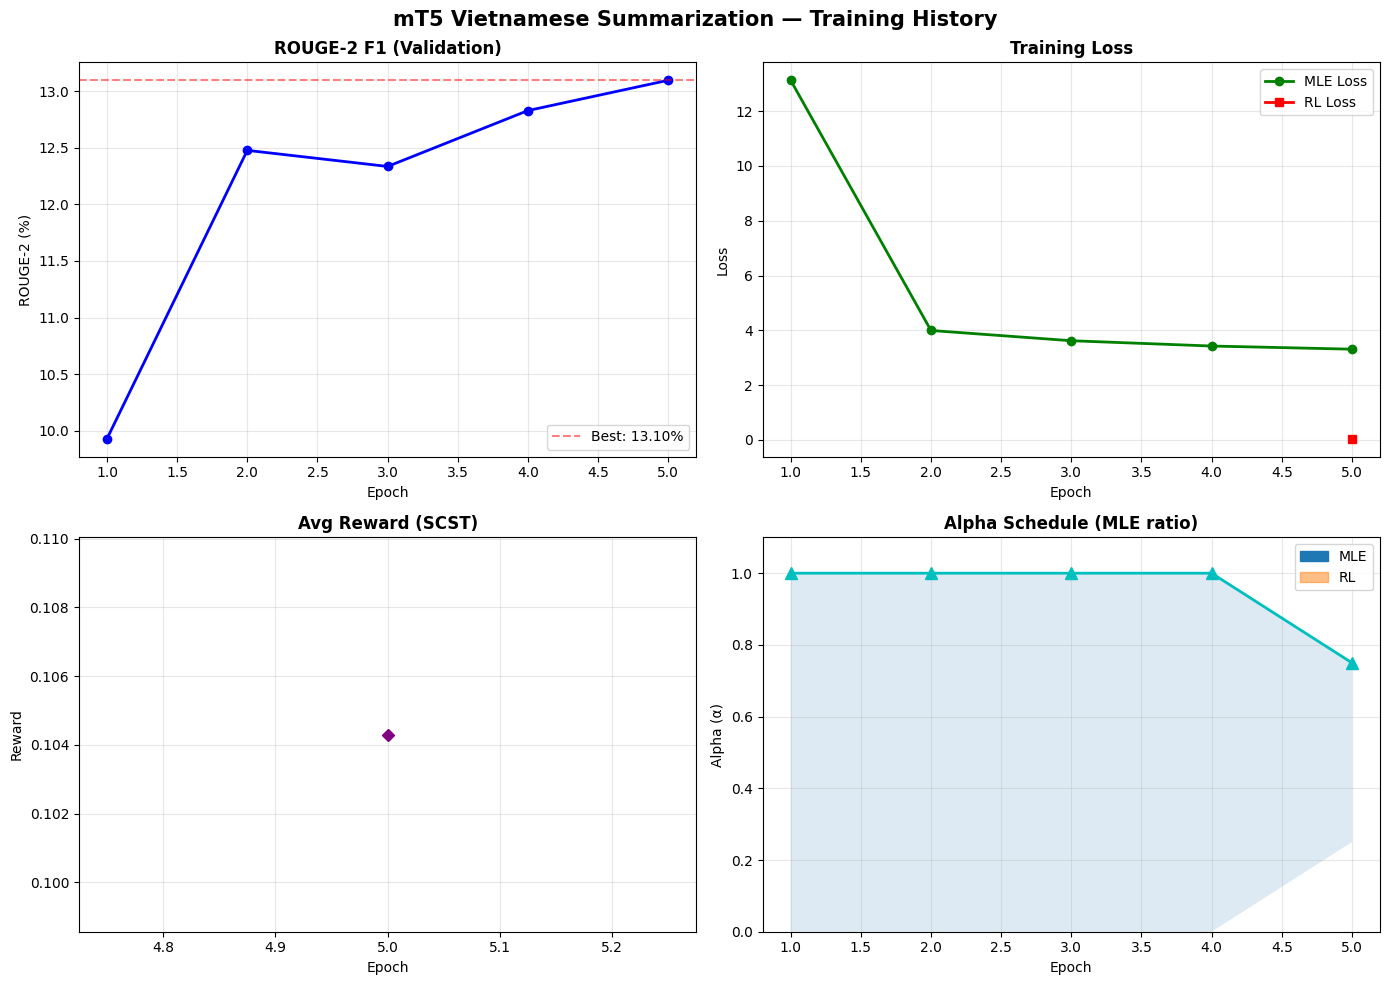

✅ Lưu biểu đồ: training_history.png


In [21]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_training_history(history):
    epochs     = [h['epoch']          for h in history]
    rouge2     = [h['rouge2']         for h in history]
    mle_loss   = [h['train_mle_loss'] for h in history]
    rl_loss    = [h.get('train_rl_loss', None) for h in history]
    avg_reward = [h.get('avg_reward',   None) for h in history]
    alphas     = [h['alpha']           for h in history]
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('mT5 Vietnamese Summarization — Training History',
                 fontsize=15, fontweight='bold')
    
    # ROUGE-2
    ax = axes[0,0]
    ax.plot(epochs, rouge2, 'b-o', linewidth=2, markersize=6)
    ax.set_title('ROUGE-2 F1 (Validation)', fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('ROUGE-2 (%)')
    ax.grid(True, alpha=0.3)
    ax.axhline(max(rouge2), color='r', linestyle='--', alpha=0.5,
               label=f'Best: {max(rouge2):.2f}%')
    ax.legend()
    
    # MLE Loss
    ax = axes[0,1]
    ax.plot(epochs, mle_loss, 'g-o', linewidth=2, markersize=6, label='MLE Loss')
    rl_vals = [(e,v) for e,v in zip(epochs,rl_loss) if v is not None]
    if rl_vals:
        ex, ey = zip(*rl_vals)
        ax.plot(ex, ey, 'r-s', linewidth=2, markersize=6, label='RL Loss')
    ax.set_title('Training Loss', fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(True, alpha=0.3)
    
    # Reward
    ax = axes[1,0]
    r_vals = [(e,v) for e,v in zip(epochs,avg_reward) if v is not None]
    if r_vals:
        ex, ey = zip(*r_vals)
        ax.plot(ex, ey, 'm-D', linewidth=2, markersize=6, color='purple')
        ax.set_title('Avg Reward (SCST)', fontweight='bold')
        ax.set_xlabel('Epoch'); ax.set_ylabel('Reward')
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'RL chưa bắt đầu\n(epoch < mle_warmup)',
                ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_title('Avg Reward (SCST)', fontweight='bold')
    
    # Alpha schedule
    ax = axes[1,1]
    ax.plot(epochs, alphas, 'c-^', linewidth=2, markersize=8)
    ax.fill_between(epochs, alphas, [1-a for a in alphas],
                    alpha=0.15, label='RL ratio')
    ax.set_title('Alpha Schedule (MLE ratio)', fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Alpha (α)')
    ax.set_ylim(0, 1.1); ax.grid(True, alpha=0.3)
    mle_p = mpatches.Patch(color='C0', label='MLE')
    rl_p  = mpatches.Patch(color='C1', alpha=0.5, label='RL')
    ax.legend(handles=[mle_p, rl_p])
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Lưu biểu đồ: training_history.png")

if history:
    plot_training_history(history)
else:
    print("⚠️  Chưa có history để vẽ.")


## 11. Inference & Demo

In [ ]:
# THÊM CÁC DÒNG IMPORT VÀO ĐÂY
!pip install rouge-score -q
import rouge_score.rouge_scorer
import torch
from typing import Dict

class VietnameseSummarizer:
    """
    [ĐÃ SỬA LỖI TOKENIZER]
    Phân tách rõ ràng: 
    - encoder_tokenizer cho text đầu vào (PhoBERT)
    - decoder_tokenizer cho text tóm tắt đầu ra (mT5)
    """
    def __init__(self, model, encoder_tokenizer, decoder_tokenizer, cfg, device=DEVICE):
        self.model             = model
        self.encoder_tokenizer = encoder_tokenizer
        self.decoder_tokenizer = decoder_tokenizer
        self.cfg               = cfg
        self.device            = device
        self.preprocessor      = VietnamesePreprocessor()
    
    def summarize(self, text: str, method='beam', **kwargs) -> Dict:
        text_clean = self.preprocessor.normalize(text)
        
        # SỬA LỖI: Dùng encoder_tokenizer (PhoBERT) để mã hóa đầu vào
        inputs = self.encoder_tokenizer(
            self.cfg.prefix + text_clean,
            return_tensors='pt',
            max_length=self.cfg.max_input_len,
            truncation=True,
            padding='max_length'
        ).to(self.device)
        
        gen_kwargs = {
            'max_length': kwargs.get('max_length', self.cfg.max_target_len),
            'min_length': kwargs.get('min_length', 15),
        }
        
        if method == 'beam':
            gen_kwargs.update({
                'num_beams':             kwargs.get('num_beams', 4),
                'no_repeat_ngram_size':  3,
                'early_stopping':        True,
                'length_penalty':        kwargs.get('length_penalty', 2.0),
            })
        elif method == 'sampling':
            gen_kwargs.update({
                'do_sample':   True,
                'top_p':       kwargs.get('top_p', 0.9),
                'temperature': kwargs.get('temperature', 0.8),
                'num_return_sequences': kwargs.get('num_return', 2),
            })
        
        with torch.no_grad():
            try:
                out_ids = self.model.generate(
                    input_ids=inputs['input_ids'],
                    attention_mask=inputs['attention_mask'],
                    **gen_kwargs
                )
            except Exception as e:
                # Fallback an toàn
                out_ids = self.model.generate(
                    input_ids=inputs['input_ids'],
                    attention_mask=inputs['attention_mask'],
                    max_length=gen_kwargs['max_length'],
                )
        
        # SỬA LỖI: Dùng decoder_tokenizer (mT5) để giải mã đầu ra
        summaries = self.decoder_tokenizer.batch_decode(out_ids, skip_special_tokens=True)
        
        # Đã nhận diện được rouge_score nhờ lệnh import ở trên cùng
        r_scorer = rouge_score.rouge_scorer.RougeScorer(['rouge1','rouge2','rougeL'])
        results = []
        for summ in summaries:
            score = r_scorer.score(text_clean, summ)
            results.append({
                'summary':   summ,
                'rouge1':    round(score['rouge1'].fmeasure * 100, 2),
                'rouge2':    round(score['rouge2'].fmeasure * 100, 2),
                'rougeL':    round(score['rougeL'].fmeasure * 100, 2),
                'compress':  f"{len(summ.split())/max(len(text.split()),1)*100:.1f}%",
            })
        
        return results

# KHỞI TẠO LẠI VỚI 2 TOKENIZER RIÊNG BIỆT
summarizer = VietnameseSummarizer(model, encoder_tokenizer, decoder_tokenizer, cfg, DEVICE)
print("✅ VietnameseSummarizer sẵn sàng!")

In [ ]:
# ─── Demo tóm tắt ───────────────────────────────────────────────────────────

test_texts = [

    """Hà Nội, ngày 15 tháng 3 năm 2024. Ủy ban nhân dân thành phố Hà Nội

    vừa tổ chức hội nghị tổng kết công tác phòng chống dịch COVID-19 và

    triển khai kế hoạch phát triển kinh tế xã hội năm 2024. Theo báo cáo

    của Sở Y tế Hà Nội, trong năm 2023, thành phố đã kiểm soát tốt dịch

    bệnh với tỷ lệ tiêm vaccine đạt 95% dân số. UBND thành phố đặt mục tiêu

    tăng trưởng GRDP đạt 7,5% trong năm 2024, tập trung vào phát triển công

    nghệ số và thu hút đầu tư nước ngoài. Nhiều dự án hạ tầng trọng điểm

    cũng sẽ được đẩy nhanh tiến độ trong năm nay.""",

    

    """Ngân hàng Nhà nước Việt Nam vừa công bố báo cáo tài chính quý I

    năm 2024. Theo đó, tổng phương tiện thanh toán tăng 1,2% so với cuối

    năm 2023. Lãi suất huy động bình quân của các ngân hàng thương mại dao

    động từ 4,5 đến 5,5% mỗi năm. Tín dụng toàn nền kinh tế tăng 2,5%

    so với cuối năm trước. Ngân hàng Nhà nước tiếp tục điều hành chính sách

    tiền tệ linh hoạt nhằm kiểm soát lạm phát mục tiêu 4% và hỗ trợ tăng

    trưởng kinh tế theo mục tiêu Quốc hội giao.""",

]



for i, text in enumerate(test_texts, 1):

    print(f"\n{'='*65}")

    print(f"VĂN BẢN {i}:")

    print(f"  {text[:150].strip()}...")

    print(f"  (Độ dài: {len(text.split())} từ)")

    

    print(f"\n── BEAM SEARCH (4 beams) ──────────────────────────────────")

    results = summarizer.summarize(text, method='beam', num_beams=4)

    for r in results:

        print(f"  📝 {r['summary']}")

        print(f"     ROUGE-1={r['rouge1']}  ROUGE-2={r['rouge2']}  "

              f"ROUGE-L={r['rougeL']}  Nén={r['compress']}")

    

    print(f"\n── SAMPLING (top-p=0.9) ───────────────────────────────────")

    results_s = summarizer.summarize(text, method='sampling',

                                     top_p=0.9, num_return=2)

    for j, r in enumerate(results_s, 1):

        print(f"  [{j}] {r['summary']}")

        print(f"       ROUGE-1={r['rouge1']}  ROUGE-2={r['rouge2']}  "

              f"ROUGE-L={r['rougeL']}")



print(f"\n{'='*65}")

print("✅ Demo hoàn tất!")



## 12. Đánh giá toàn diện trên tập Validation

In [ ]:
# ─── Đánh giá trên tập Validation ───────────────────────────────────────────
print("⏳ Đánh giá mô hình trên validation set...")

val_data   = dataset['validation']
n_eval     = min(200, len(val_data))
val_sample = val_data.select(range(n_eval))
sources    = val_sample[src_col]
references = val_sample[tgt_col]
predictions = []

model.eval()
for i in range(0, len(sources), cfg.batch_size):
    batch_src = sources[i : i + cfg.batch_size]
    inputs = encoder_tokenizer(
        [cfg.prefix + preprocessor.normalize(t) for t in batch_src],
        return_tensors='pt', max_length=cfg.max_input_len,
        truncation=True, padding=True
    ).to(DEVICE)
    with torch.no_grad():
        try:
            out = model.generate(
                input_ids=inputs['input_ids'],
                attention_mask=inputs['attention_mask'],
                max_length=cfg.max_target_len,
                num_beams=4, early_stopping=True,
                no_repeat_ngram_size=3, length_penalty=2.0
            )
        except Exception:
            out = model.generate(
                input_ids=inputs['input_ids'],
                attention_mask=inputs['attention_mask'],
                max_length=cfg.max_target_len,
            )
    predictions.extend(tokenizer.batch_decode(out, skip_special_tokens=True))
    print(f"  Processed {min(i+cfg.batch_size, len(sources))}/{len(sources)}", end='\r')

print("\n")
final_results = evaluator.evaluate(sources, predictions, references, verbose=True)

# ── Lưu kết quả JSON ─────────────────────────────────────────────────────────
os.makedirs(cfg.output_dir, exist_ok=True)
flat = {}
for k, v in final_results.items():
    if isinstance(v, dict):
        for k2, v2 in v.items():
            if isinstance(v2, dict):
                for k3, v3 in v2.items():
                    flat[f"{k}_{k2}_{k3}"] = v3
            else:
                flat[f"{k}_{k2}"] = v2
    else:
        flat[k] = v
with open(f"{cfg.output_dir}/eval_results_validation.json", 'w', encoding='utf-8') as f:
    json.dump(flat, f, ensure_ascii=False, indent=2)
print(f"✅ Lưu kết quả: {cfg.output_dir}/eval_results_validation.json")


## 13. Lưu & Load Mô hình

In [ ]:
# Lưu toàn bộ config + weights
import json

def save_model(model, tokenizer, cfg, path):
    os.makedirs(path, exist_ok=True)
    torch.save(model.state_dict(), f"{path}/model_weights.pt")
    tokenizer.save_pretrained(path)
    with open(f"{path}/training_config.json", 'w') as f:
        json.dump(vars(cfg), f, indent=2)
    if history:
        with open(f"{path}/training_history.json", 'w') as f:
            json.dump(history, f, indent=2)
    print(f"✅ Model lưu tại: {path}")
    print(f"   Files: {os.listdir(path)}")

def load_model(path, cfg, device=DEVICE):
    model = ViSumModel(cfg).to(device)
    model.load_state_dict(
        torch.load(f"{path}/model_weights.pt", map_location=device)
    )
    tokenizer = AutoTokenizer.from_pretrained(path)
    model.eval()
    print(f"✅ Model load từ: {path}")
    return model, tokenizer

# Lưu model hiện tại
save_model(model, tokenizer, cfg, f"{cfg.output_dir}/final_model")


In [ ]:
# ─── Đánh giá trên tập Test (chạy sau khi có test.parquet) ──────────────────
# Bỏ comment toàn bộ khi đã load test_dataset ở cell 4.4

# print("⏳ Đánh giá mô hình trên test set...")
# test_sources    = test_dataset[src_col]
# test_references = test_dataset[tgt_col]
# test_predictions = []
#
# model.eval()
# for i in range(0, len(test_sources), cfg.batch_size):
#     batch_src = test_sources[i : i + cfg.batch_size]
#     inputs = encoder_tokenizer(
#         [cfg.prefix + preprocessor.normalize(t) for t in batch_src],
#         return_tensors='pt', max_length=cfg.max_input_len,
#         truncation=True, padding=True
#     ).to(DEVICE)
#     with torch.no_grad():
#         out = model.generate(
#             input_ids=inputs['input_ids'],
#             attention_mask=inputs['attention_mask'],
#             max_length=cfg.max_target_len,
#             num_beams=4, early_stopping=True,
#             no_repeat_ngram_size=3, length_penalty=2.0
#         )
#     test_predictions.extend(tokenizer.batch_decode(out, skip_special_tokens=True))
#     print(f"  {min(i+cfg.batch_size, len(test_sources))}/{len(test_sources)}", end='\r')
#
# print("\nTest set results:")
# test_results = evaluator.evaluate(test_sources, test_predictions,
#                                    test_references, verbose=True)
#
# # So sánh Validation vs Test
# print("\n📊 So sánh Validation vs Test:")
# for metric in ['rouge1','rouge2','rougeL']:
#     val_f1  = final_results['rouge'][metric]['fmeasure'] * 100
#     test_f1 = test_results['rouge'][metric]['fmeasure'] * 100
#     diff    = test_f1 - val_f1
#     sign    = '+' if diff >= 0 else ''
#     print(f"  {metric.upper():<10} Val={val_f1:.2f}%  Test={test_f1:.2f}%  "
#           f"Δ={sign}{diff:.2f}%")
#
# with open(f"{cfg.output_dir}/eval_results_test.json", 'w', encoding='utf-8') as f:
#     json.dump(test_results, f, ensure_ascii=False, indent=2, default=str)

print("ℹ️  Cell này đánh giá trên test set.")
print("   Bỏ comment sau khi load test.parquet ở cell 4.4.")


In [ ]:
# ─── Tóm tắt kết quả cuối ──────────────────────────────────────────────────
print("\n" + "🏆 " * 20)
print("  KẾT QUẢ HUẤN LUYỆN TỔNG KẾT")
print("🏆 " * 20)
print(f"\n  Mô hình:  PhoBERT-base-v2 Encoder + mT5-small Decoder")
print(f"  Dataset:  Custom Vietnamese Parquet (train + valid)")
print(f"  Epochs:   {cfg.num_epochs}  (MLE warmup: {cfg.mle_warmup_epochs})")
print(f"  RL:       SCST (Self-Critical Sequence Training)")
print(f"  Reward:   ROUGE({cfg.w_rouge}) + Length({cfg.w_length})")

if final_results:
    r = final_results['rouge']
    print(f"\n  📊 ROUGE Scores:")
    print(f"     ROUGE-1 F1:   {r['rouge1']['fmeasure']*100:.2f}%")
    print(f"     ROUGE-2 F1:   {r['rouge2']['fmeasure']*100:.2f}%")
    print(f"     ROUGE-L F1:   {r['rougeL']['fmeasure']*100:.2f}%")
    
    if final_results.get('bertscore',{}).get('bertscore_f1'):
        print(f"\n  🤖 BERTScore (PhoBERT):")
        print(f"     F1:           {final_results['bertscore']['bertscore_f1']:.2f}%")
    
    st = final_results.get('statistics', {})
    print(f"\n  📈 Statistics:")
    print(f"     Compression:  {st.get('compression_ratio', 0):.1f}%")
    print(f"     Coverage:     {st.get('coverage', 0):.1f}%")
    print(f"     Novelty-1:    {st.get('novelty_1gram', 0):.1f}%")

print(f"\n  💾 Model saved: {cfg.output_dir}/final_model")
print("\n" + "✅ " * 20)
